In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
 
df = pd.read_csv("../data/heart.csv")

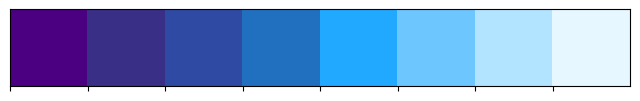

In [67]:
palette_color = ["#4B0082", "#3a2f87", "#2e4aa3", "#2170c0", "#21A9FF", "#6DC6FE", "#B3E4FF", "#E6F7FF"]

df_style = {
    "border": "1px solid black",
    "text-align": "center",
    "border-collapse": "collapse",
    "font-size": "14px",
    "background-color": palette_color[-4],
    "color": "white",
    "padding": "15px"
}

table_style = [
    {"selector": "th", "props": [("background-color", palette_color[0]), ("border", "1px solid black"), ("color", "white")]},
    {"selector": "th.col_heading", "props": [("background-color", palette_color[0]), ("border", "1px solid black"), ("color", "white"), ("padding", "10px")]},
    {"selector": "th.row_heading", "props": [("background-color", palette_color[0]), ("border", "1px solid black"), ("color", "white"), ("padding", "10px")]},
    {"selector": "tr:nth-child(even) td", "props": [("background-color", palette_color[2])]},
    {"selector": "tr:nth-child(odd) td", "props": [("background-color", palette_color[1])]},
    {"selector": "td", "props": [("border", "1px solid black")]},
]

sns.palplot(sns.color_palette(palette_color))

In [68]:
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500000,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000000,Up,0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Num cols: {num_cols}")
print(f"Cat cols: {cat_cols}")

Num cols: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Cat cols: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [72]:
df.describe().T.style.set_properties(**df_style).set_table_styles(table_style)

,count,mean,std,min,25%,50%,75%,max
Age,918.000000,53.510893,9.432617,28.000000,47.000000,54.000000,60.000000,77.000000
RestingBP,918.000000,132.396514,18.514154,0.000000,120.000000,130.000000,140.000000,200.000000
Cholesterol,918.000000,198.799564,109.384145,0.000000,173.250000,223.000000,267.000000,603.000000
FastingBS,918.000000,0.233115,0.423046,0.000000,0.000000,0.000000,0.000000,1.000000
MaxHR,918.000000,136.809368,25.460334,60.000000,120.000000,138.000000,156.000000,202.000000
Oldpeak,918.000000,0.887364,1.066570,-2.600000,0.000000,0.600000,1.500000,6.200000
HeartDisease,918.000000,0.553377,0.497414,0.000000,0.000000,1.000000,1.000000,1.000000


In [73]:
df.describe(include="object").T.style.set_properties(**df_style).set_table_styles(table_style)

,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


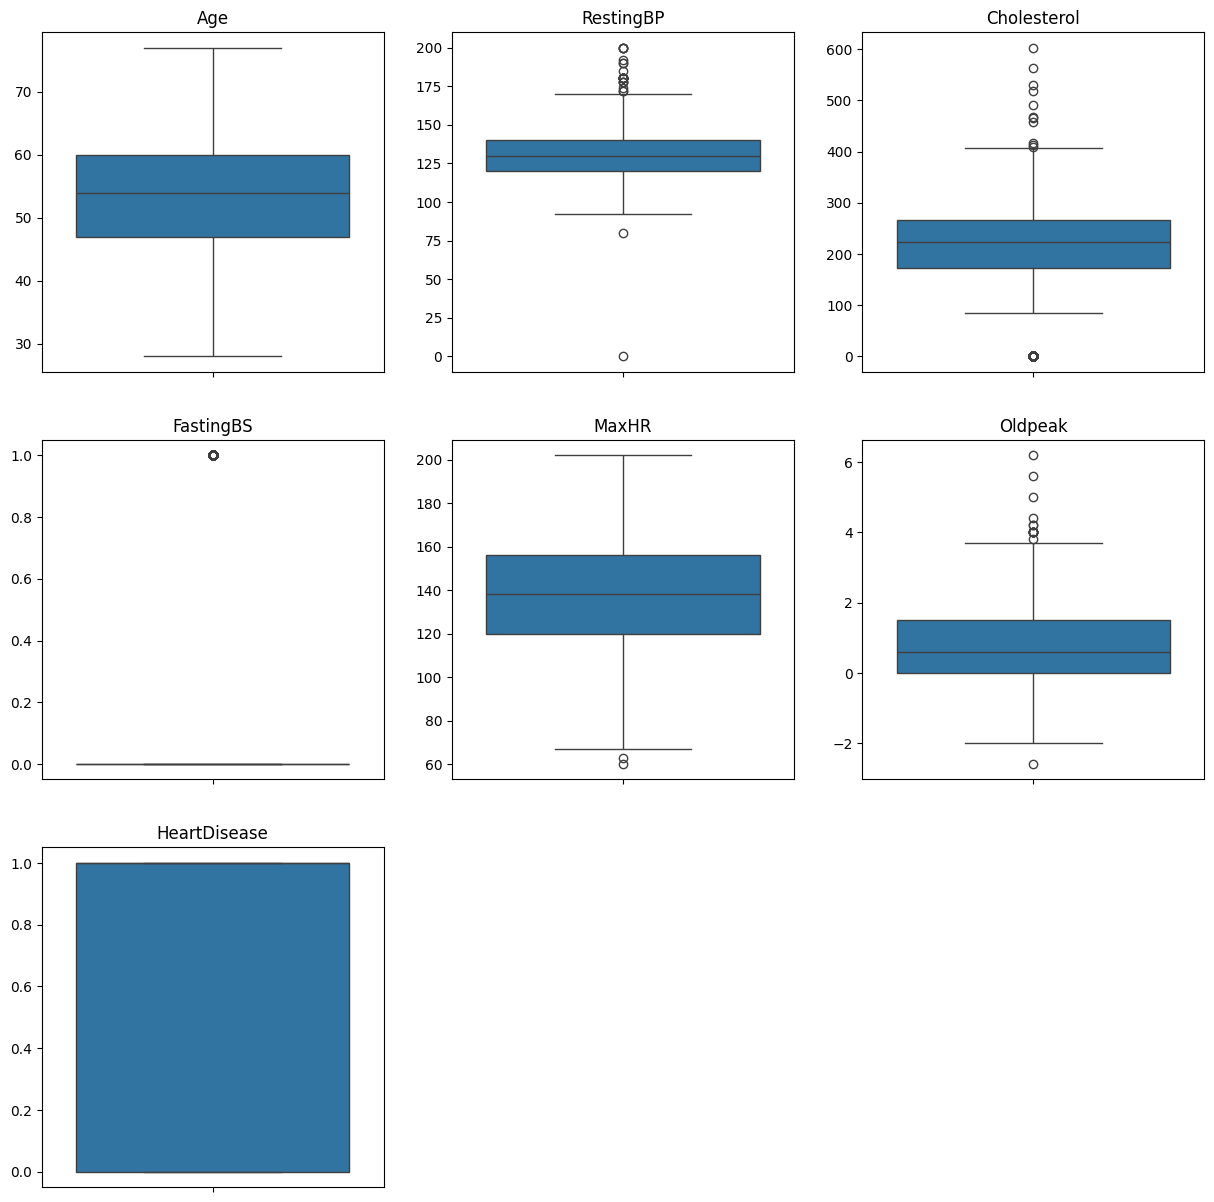

In [74]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
ax = ax.flatten()

for i, col in enumerate(num_cols):
  data = df[col]

  ax[i].set_title(col)
  sns.boxplot(
      y=data,
      ax=ax[i]
  )
  ax[i].set_ylabel(None)

for j in range(len(num_cols), n_rows * n_cols):
  fig.delaxes(ax[j])

plt.show()

In [75]:
out_cols = ["RestingBP", "Cholesterol", "Oldpeak"]

df_clear_out = df.copy()

for col in out_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q3 - 1.50 * iqr
  upper_bound = q3 + 1.50 * iqr
  
  df_clear_out = df_clear_out[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df_clear_out.shape

C:\Users\Admin\AppData\Local\Temp\ipykernel_7200\4196922828.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clear_out = df_clear_out[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
C:\Users\Admin\AppData\Local\Temp\ipykernel_7200\4196922828.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clear_out = df_clear_out[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


(660, 12)

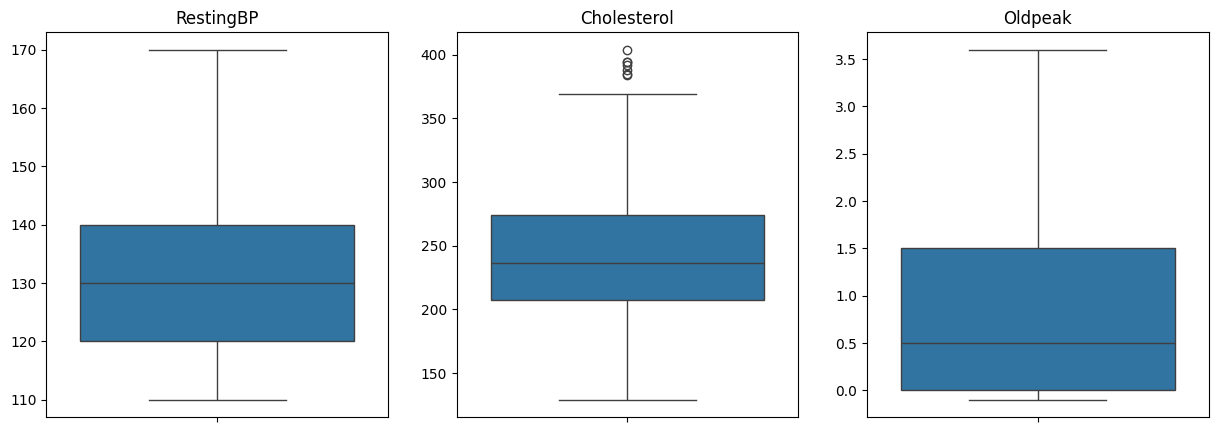

In [76]:
n_cols = 3
n_rows = math.ceil(len(out_cols) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
ax = ax.flatten()

for i, col in enumerate(out_cols):
  data = df_clear_out[col]

  ax[i].set_title(col)
  sns.boxplot(
      y=data,
      ax=ax[i]
  )
  ax[i].set_ylabel(None)

for j in range(len(out_cols), n_rows * n_cols):
  fig.delaxes(ax[j])

plt.show()

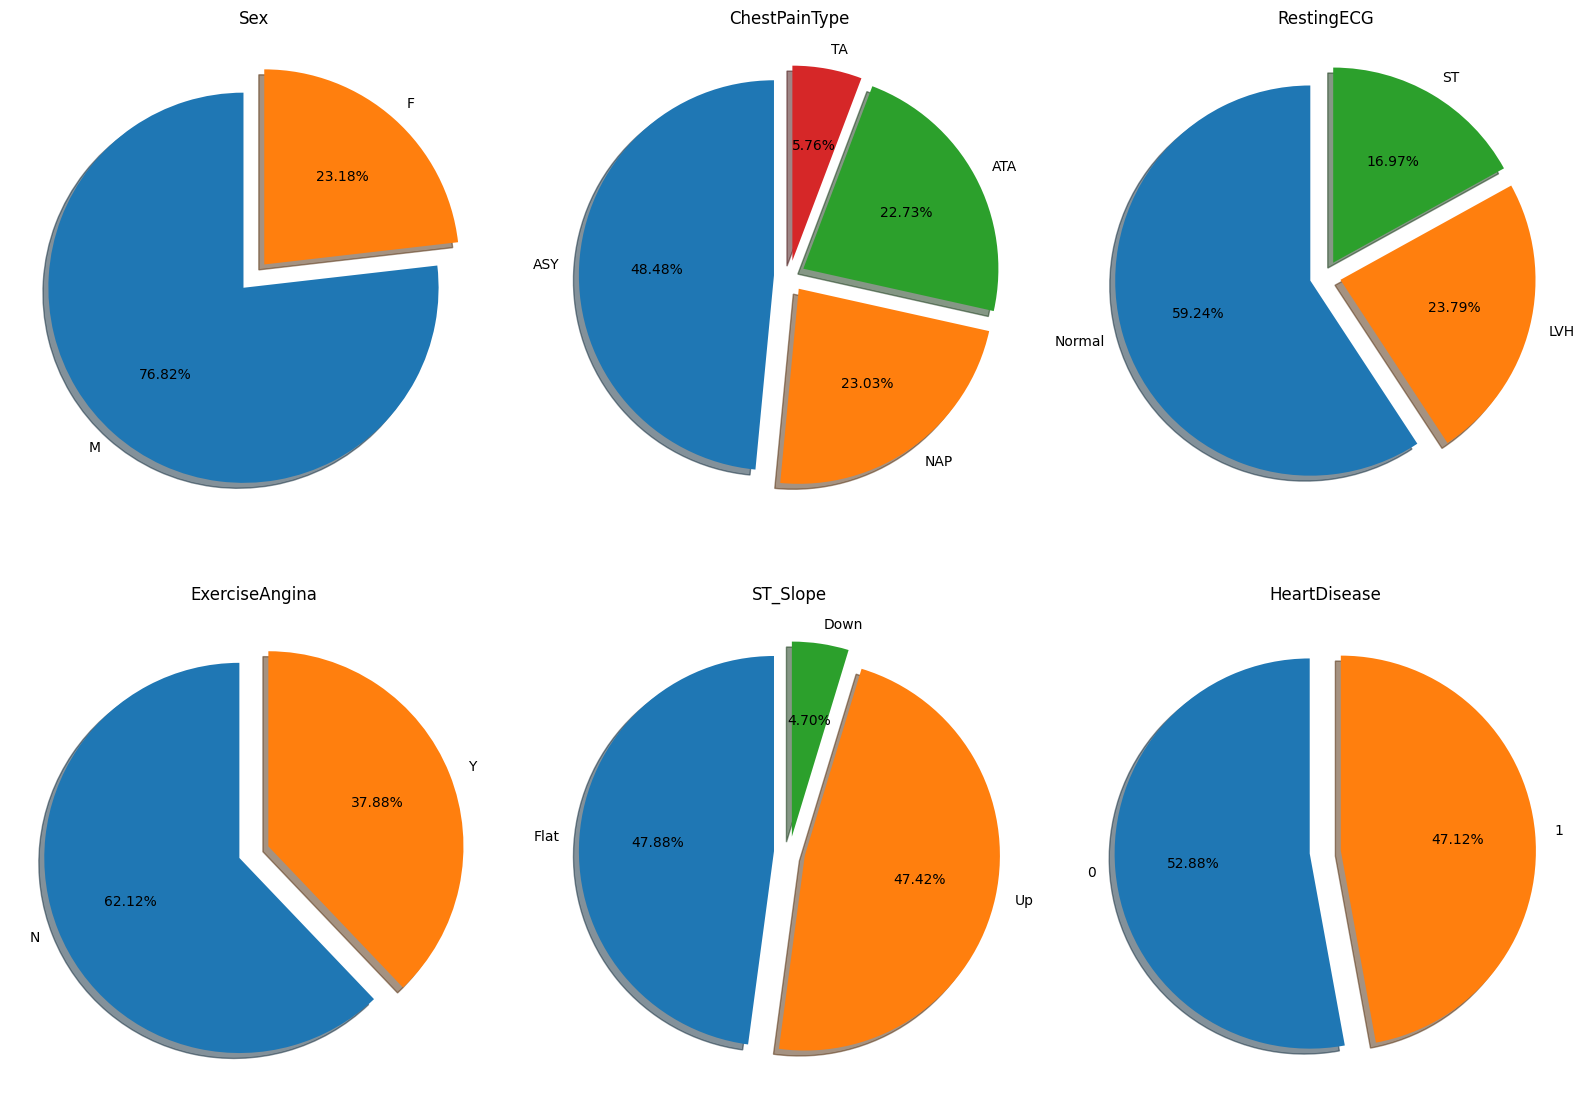

In [77]:
f_pie_cols = cat_cols + ["HeartDisease"]

n_cols = 3
n_rows = math.ceil(len(f_pie_cols) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*8, n_cols*4))
ax = ax.flatten()

for i, col in enumerate(f_pie_cols):
  data = df_clear_out[col].value_counts()
  
  ax[i].set_title(col)
  wedges, texts, autotexts = ax[i].pie(
    x=data,
    labels=data.keys(),
    autopct="%.2f%%",
    startangle=90,
    shadow=True,
    explode=[0.08 for _ in range(len(data.keys()))]
  )
  
for j in range(len(f_pie_cols), n_rows * n_cols):
  fig.delaxes(ax[j])
    
plt.tight_layout()
plt.show()

### Sampling

In [ ]:
def oversampling(X, y):
  df = pd.DataFrame(X)
  name = y.to_frame().columns[0]
  df[name] = y
  
  classes = df[name].unique()
  max_count = df[name].value_counts().max()
  # min_count = df[name].value_counts().min() # under sampler
  
  df_balanced = pd.concat([ 
    df[df[name] == c].sample(max_count, replace=True, random_state=42)
    for c in classes
  ])
  
  return df_balanced

In [79]:
df_balanced = oversampling(df_clear_out.drop(columns=["Sex"]), df.Sex)
df_balanced.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex
162,47,ATA,160,263,0,Normal,174,N,0.0,Up,0,M
808,35,ASY,126,282,0,LVH,156,Y,0.0,Up,1,M
653,42,NAP,130,180,0,Normal,150,N,0.0,Up,0,M
556,75,ASY,160,310,1,Normal,112,Y,2.0,Down,0,M
168,58,ASY,135,222,0,Normal,100,N,0.0,Up,0,M


(1014, 12)


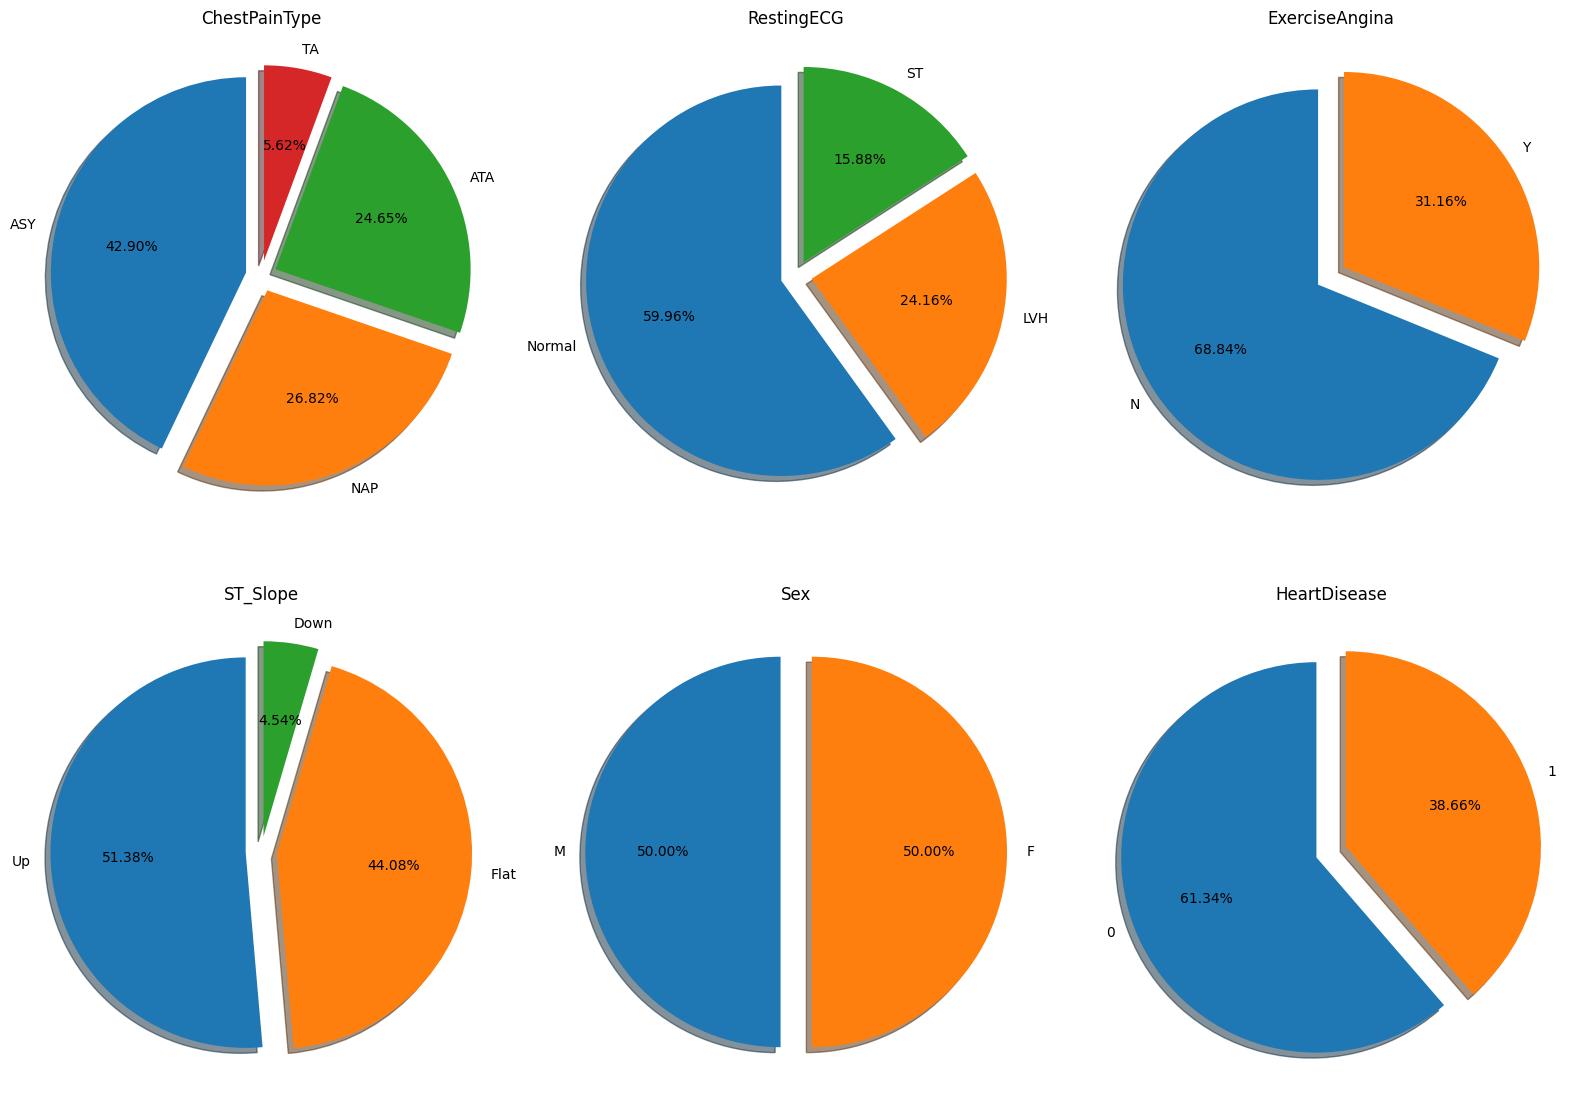

In [80]:
print(df_balanced.shape)

f_pie_cols = df_balanced.select_dtypes("object").columns.to_list() + ["HeartDisease"]

n_cols = 3
n_rows = int(np.ceil(len(f_pie_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*8, n_cols*4))
ax = ax.flatten()

for i, col in enumerate(f_pie_cols):
  data = df_balanced[col].value_counts()
  
  ax[i].set_title(col)
  wedges, texts, autotexts = ax[i].pie(
    x=data,
    labels=data.keys(),
    autopct="%.2f%%",
    startangle=90,
    shadow=True,
    explode=[0.08 for _ in range(len(data.keys()))]
  )
  
for j in range(len(f_pie_cols), n_rows * n_cols):
  fig.delaxes(ax[j])
    
plt.tight_layout()
plt.show()

### Encoding

In [81]:
def label_decode(df: pd.DataFrame):
  unq_map = dict()
  for col in cat_cols:
    unq = df[col].unique()
    unq_map[col] = {v: k for k, v in enumerate(unq)}
    df[col] = df[col].map(unq_map[col])
    
  return df, unq_map

df_encoded, struct = label_decode(df)

df_encoded.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0


In [82]:
struct

{'Sex': {'M': 0, 'F': 1},
 'ChestPainType': {'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3},
 'RestingECG': {'Normal': 0, 'ST': 1, 'LVH': 2},
 'ExerciseAngina': {'N': 0, 'Y': 1},
 'ST_Slope': {'Up': 0, 'Flat': 1, 'Down': 2}}

### Sclaer

In [83]:
def min_max_scaler(X: pd.DataFrame):
  return ((X - X.min(axis=0)) / (X.max(axis=0) - X.mean(axis=0)))

def z_score(X: pd.DataFrame):
  return ((X - X.mean(axis=0)) / X.std(axis=0))

In [84]:
df_mm_scaler = min_max_scaler(df_encoded)
df_mm_scaler.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.510875,0.000000,0.000000,2.070899,0.714992,0.0,0.000000,1.718038,0.000000,0.489399,0.0000,0.000000
1,0.894031,1.266207,0.646024,2.366742,0.445324,0.0,0.000000,1.472604,0.000000,0.677630,0.7344,2.239024
2,0.383156,0.000000,0.000000,1.922978,0.700148,0.0,0.716069,0.582906,0.000000,0.489399,0.0000,0.000000
3,0.851459,1.266207,1.292048,2.041315,0.529440,0.0,0.000000,0.736302,1.678245,0.771745,0.7344,2.239024
4,1.106896,0.000000,0.646024,2.218820,0.482434,0.0,0.000000,0.951057,0.000000,0.489399,0.0000,0.000000


In [85]:
df_std_scaler = min_max_scaler(df_encoded)
df_std_scaler.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.510875,0.000000,0.000000,2.070899,0.714992,0.0,0.000000,1.718038,0.000000,0.489399,0.0000,0.000000
1,0.894031,1.266207,0.646024,2.366742,0.445324,0.0,0.000000,1.472604,0.000000,0.677630,0.7344,2.239024
2,0.383156,0.000000,0.000000,1.922978,0.700148,0.0,0.716069,0.582906,0.000000,0.489399,0.0000,0.000000
3,0.851459,1.266207,1.292048,2.041315,0.529440,0.0,0.000000,0.736302,1.678245,0.771745,0.7344,2.239024
4,1.106896,0.000000,0.646024,2.218820,0.482434,0.0,0.000000,0.951057,0.000000,0.489399,0.0000,0.000000


In [86]:
df_no_scaler = df_encoded.copy()
df_no_scaler.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0


### Split

In [87]:
def train_test_split(X, y, test_size=0.2, random_state=None):
  if random_state:
    np.random.seed(random_state)
  
  n_sample = len(X)
  
  shuffle_indices = np.random.permutation(np.arange(n_sample))
  
  test_size = round(test_size * n_sample)
  train_size = n_sample - test_size
  
  train_indices = shuffle_indices[:train_size]
  test_indices = shuffle_indices[test_size:]
  
  X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
  y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
  
  return [X_train, X_test, y_train, y_test]

In [88]:
X = df_no_scaler.drop(columns=["HeartDisease"])
y = df_no_scaler["HeartDisease"]

X_no_train, X_no_test, y_no_train, y_no_test = train_test_split(X, y, random_state=42)

In [89]:
X = df_mm_scaler.drop(columns=["HeartDisease"])
y = df_mm_scaler["HeartDisease"]

X_mm_train, X_mm_test, y_mm_train, y_mm_test = train_test_split(X, y, random_state=42)

In [90]:
X = df_std_scaler.drop(columns=["HeartDisease"])
y = df_std_scaler["HeartDisease"]

X_std_train, X_std_test, y_std_train, y_std_test = train_test_split(X, y, random_state=42)

### Build Model

In [ ]:
class KNN:
  def __init__(self, k:int, p:int):
    self.k = k
    self.p = p
  
  def _minkowski_distance(self, X, y):
    return np.power(np.sum(np.abs(X - y) ** self.p), 1/self.p)
  
  def fit(self, X, y):
    self.X_train = X
    self.y_train = y  
  
  def predict(self, X):
    preds = [self._predict_process(x) for x in X]
    return np.array(preds)
  
  def _predict_process(self, X):
    # Komputai jarak antara x dan semua training set
    distances = [self._minkowski_distance(X, x_train) for x_train in self.X_train]
    # Urutkan berdasarkan jarak dan jadikan indexs dari k neighbors pertama
    k_indices = np.argsort(distances)[:self.k]
    # Esktrak label training sampel dari knn
    k_nearest_labels = [self.y_train[i] for i in k_indices]
    # mendapatkan class label paling terdekat
    return np.bincount(k_nearest_labels).argmax() 

In [114]:
model = KNN(k=5, p=1)
model.fit(X_no_train.to_numpy(), y_no_train.to_numpy())

pred = model.predict(X_no_test.to_numpy())

### Evaluation

In [ ]:
class 